In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [ ]:
# Load dataset
df = pd.read_csv("/content/multiple.csv")

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 91  
1                                 2                 65  
2                                 2                 45  
3                                 2                 36  
4                                 5                 66  


In [ ]:
# Check missing values
print(df.isnull().sum())

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [ ]:
# Define features and target
X = df.drop("Performance Index", axis=1)
Y = df["Performance Index"]

In [ ]:
# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [ ]:
# Create Multiple Linear Regression model
model = LinearRegression()

In [ ]:
import pandas as pd
X_train = pd.get_dummies(X_train, columns=['Extracurricular Activities'], drop_first=True)
# Train model
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predictions
X_test = pd.get_dummies(X_test, columns=['Extracurricular Activities'], drop_first=True)
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)

In [ ]:
#slope
print(model.coef_)

[2.97225412 1.01252083 0.39390125 0.25123229 1.2369383 ]


In [ ]:
#intercept
print(model.intercept_)

-34.69530067260657


In [ ]:
# Training Evaluation
print("\nTraining Results")
print("R2 Score :", r2_score(Y_train, Y_train_pred))
print("MAE      :", mean_absolute_error(Y_train, Y_train_pred))
print("MSE      :", mean_squared_error(Y_train, Y_train_pred))
print("RMSE     :", np.sqrt(mean_squared_error(Y_train, Y_train_pred)))
print("MAPE     :", mean_absolute_percentage_error(Y_train, Y_train_pred))


Training Results
R2 Score : 0.9907349505067465
MAE      : 1.3475858846704292
MSE      : 2.824335514755352
RMSE     : 1.6805759473333397
MAPE     : 0.028811496031442257


In [ ]:
# Testing Evaluation
print("\nTesting Results")
print("R2 Score :", r2_score(Y_test, Y_test_pred))
print("MAE      :", mean_absolute_error(Y_test, Y_test_pred))
print("MSE      :", mean_squared_error(Y_test, Y_test_pred))
print("RMSE     :", np.sqrt(mean_squared_error(Y_test, Y_test_pred)))


Testing Results
R2 Score : 0.9745898025923475
MAE      : 1.6970814050061498
MSE      : 5.714499295006968
RMSE     : 2.3905018918643357


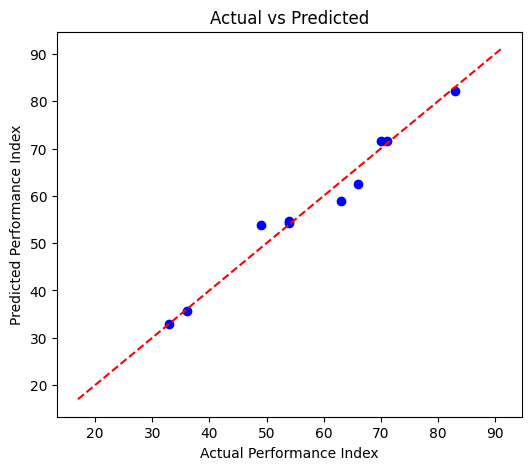

In [ ]:
# Actual vs Predicted Plot
plt.figure(figsize=(6,5))
plt.scatter(Y_test, Y_test_pred, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted")
plt.show()

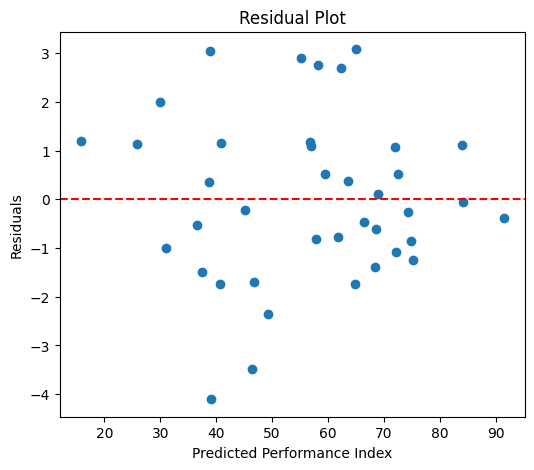

In [ ]:
residuals = Y_train - Y_train_pred

plt.figure(figsize=(6,5))
plt.scatter(Y_train_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()